In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io as sio
from scipy.io import savemat
import os
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
%matplotlib inline

In [2]:
data_dir = Path('./data2')
BRCA_path = Path("./BRCA.mat")
BRCA_data = sio.loadmat(BRCA_path)
print(BRCA_data.keys())
gene_expression = BRCA_data['BRCA_Gene_Expression'].T
print(gene_expression.shape)
methy_expression = BRCA_data['BRCA_Methy_Expression'].T
print(methy_expression.shape)
mirna_expression = BRCA_data['BRCA_Mirna_Expression'].T
print(mirna_expression.shape)
labels = BRCA_data['BRCA_clinicalMatrix'].flatten()
print(labels.shape)
indexes = BRCA_data['BRCA_indexes'].flatten()
print(indexes.shape)

dict_keys(['__header__', '__version__', '__globals__', 'BRCA_Gene_Expression', 'BRCA_Methy_Expression', 'BRCA_Mirna_Expression', 'BRCA_clinicalMatrix', 'BRCA_indexes'])
(646, 20531)
(646, 5000)
(646, 1046)
(646,)
(646,)


In [4]:
index_gene_dict = {}
index_methy_dict = {}
index_mirna_dict = {}
label_dict = {}
for idx in indexes:
    idx = int(idx)
    index_gene_dict[idx] = len(index_gene_dict)
    index_methy_dict[idx] = len(index_methy_dict)
    index_mirna_dict[idx] = len(index_mirna_dict)
    label_dict[idx] = labels[idx]
print(index_gene_dict)
print(index_methy_dict)
print(index_mirna_dict)
print(label_dict)

{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17, 18: 18, 19: 19, 20: 20, 21: 21, 22: 22, 23: 23, 24: 24, 25: 25, 26: 26, 27: 27, 28: 28, 29: 29, 30: 30, 31: 31, 32: 32, 33: 33, 34: 34, 35: 35, 36: 36, 37: 37, 38: 38, 39: 39, 40: 40, 41: 41, 42: 42, 43: 43, 44: 44, 45: 45, 46: 46, 47: 47, 48: 48, 49: 49, 50: 50, 51: 51, 52: 52, 53: 53, 54: 54, 55: 55, 56: 56, 57: 57, 58: 58, 59: 59, 60: 60, 61: 61, 62: 62, 63: 63, 64: 64, 65: 65, 66: 66, 67: 67, 68: 68, 69: 69, 70: 70, 71: 71, 72: 72, 73: 73, 74: 74, 75: 75, 76: 76, 77: 77, 78: 78, 79: 79, 80: 80, 81: 81, 82: 82, 83: 83, 84: 84, 85: 85, 86: 86, 87: 87, 88: 88, 89: 89, 90: 90, 91: 91, 92: 92, 93: 93, 94: 94, 95: 95, 96: 96, 97: 97, 98: 98, 99: 99, 100: 100, 101: 101, 102: 102, 103: 103, 104: 104, 105: 105, 106: 106, 107: 107, 108: 108, 109: 109, 110: 110, 111: 111, 112: 112, 113: 113, 114: 114, 115: 115, 116: 116, 117: 117, 118: 118, 119: 119, 120: 120, 121: 121,

In [43]:
def corr_x_y(x: np.ndarray, y: np.ndarray, eps=1e-8):
    x = x - np.mean(x, axis=-1, keepdims=True)
    y = y - np.mean(y, axis=-1, keepdims=True)
    lxy = np.dot(x, y.T)
    lxx = np.diag(np.dot(x, x.T)).reshape((-1, 1))
    lyy = np.diag(np.dot(y, y.T)).reshape((1, -1))
    corr = lxy / (np.dot(np.sqrt(lxx), np.sqrt(lyy)) + eps)
    return corr

In [26]:
gene_expression_scaled = StandardScaler().fit_transform(gene_expression)
pca = PCA(n_components=0.95)
gene_expression_pca = pca.fit_transform(gene_expression_scaled)
print(gene_expression_pca.shape)

methy_expression_scaled = StandardScaler().fit_transform(methy_expression)
pca = PCA(n_components=0.95)
methy_expression_pca = pca.fit_transform(methy_expression_scaled)
print(methy_expression_pca.shape)

mirna_expression_scaled = StandardScaler().fit_transform(mirna_expression)
pca = PCA(n_components=0.95)
mirna_expression_pca = pca.fit_transform(mirna_expression_scaled)
print(mirna_expression_pca.shape)

(646, 435)
(646, 405)
(646, 305)


<Axes: >

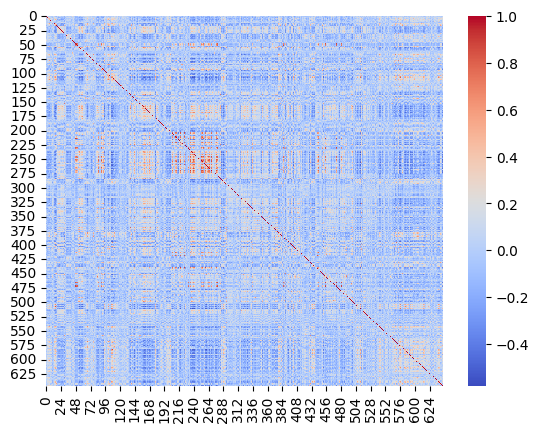

In [44]:
corr_gene = corr_x_y(gene_expression_pca, gene_expression_pca)
corr_methy = corr_x_y(methy_expression_pca, methy_expression_pca)
corr_mirna = corr_x_y(mirna_expression_pca, mirna_expression_pca)
sns.heatmap(corr_gene, cmap='coolwarm')

In [61]:
indexes_07 = np.where(np.abs(corr_gene) > 0.7)
pair_count = list(zip(indexes_07[0], indexes_07[1]))
print(len(pair_count))
print(pair_count[:10])
corr_scaled_gene = corr_x_y(gene_expression_scaled, gene_expression_scaled)
indexes_07_scaled = np.where(np.abs(corr_scaled_gene) > 0.7)
pair_count_scaled = list(zip(indexes_07_scaled[0], indexes_07_scaled[1]))
print(len(pair_count_scaled))
print(pair_count_scaled[:10])
len(set(pair_count) | set(pair_count_scaled))

1682
[(np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(2), np.int64(2)), (np.int64(3), np.int64(3)), (np.int64(4), np.int64(4)), (np.int64(5), np.int64(5)), (np.int64(6), np.int64(6)), (np.int64(7), np.int64(7)), (np.int64(8), np.int64(8)), (np.int64(9), np.int64(9))]
1016
[(np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(2), np.int64(2)), (np.int64(3), np.int64(3)), (np.int64(4), np.int64(4)), (np.int64(5), np.int64(5)), (np.int64(6), np.int64(6)), (np.int64(7), np.int64(7)), (np.int64(8), np.int64(8)), (np.int64(9), np.int64(9))]


1682

In [67]:
indexes_07 = np.where(np.abs(corr_methy) > 0.75)
pair_count = list(zip(indexes_07[0], indexes_07[1]))
print(len(pair_count))
print(pair_count[:10])
corr_scaled_methy = corr_x_y(methy_expression_scaled, methy_expression_scaled)
indexes_07_scaled = np.where(np.abs(corr_scaled_methy) > 0.75)
pair_count_scaled = list(zip(indexes_07_scaled[0], indexes_07_scaled[1]))
print(len(pair_count_scaled))
print(pair_count_scaled[:10])
len(set(pair_count) | set(pair_count_scaled))

6240
[(np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(2), np.int64(2)), (np.int64(3), np.int64(3)), (np.int64(4), np.int64(4)), (np.int64(5), np.int64(5)), (np.int64(6), np.int64(6)), (np.int64(7), np.int64(7)), (np.int64(7), np.int64(96)), (np.int64(7), np.int64(186))]
4122
[(np.int64(0), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(2), np.int64(2)), (np.int64(3), np.int64(3)), (np.int64(4), np.int64(4)), (np.int64(5), np.int64(5)), (np.int64(6), np.int64(6)), (np.int64(7), np.int64(7)), (np.int64(8), np.int64(8)), (np.int64(9), np.int64(9))]


6240

In [9]:
data_edges_95_dir = os.path.join(data_dir, 'PCA_BRCA_95')
edges_95_gene_path = os.path.join(data_edges_95_dir, 'edges_gene_brca.csv')
edges_95_methy_path = os.path.join(data_edges_95_dir, 'edges_methy_brca.csv')
edges_95_mirna_path = os.path.join(data_edges_95_dir, 'edges_mirna_brca.csv')
count_valid_edges = dict()
count_invalid_edges = dict()
for path in [edges_95_gene_path, edges_95_methy_path, edges_95_mirna_path]:
    with open(path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            node1, node2 = map(int, line.strip().split(','))
            if label_dict[node1] == label_dict[node2]:
                count_valid_edges[path] = count_valid_edges.get(path, 0) + 1
            else:
                count_invalid_edges[path] = count_invalid_edges.get(path, 0) + 1
print("Valid edges count:", count_valid_edges)
print("Invalid edges count:", count_invalid_edges)

Valid edges count: {'data2\\PCA_BRCA_95\\edges_gene_brca.csv': 2022, 'data2\\PCA_BRCA_95\\edges_methy_brca.csv': 1056, 'data2\\PCA_BRCA_95\\edges_mirna_brca.csv': 1884}
Invalid edges count: {'data2\\PCA_BRCA_95\\edges_gene_brca.csv': 424, 'data2\\PCA_BRCA_95\\edges_methy_brca.csv': 286, 'data2\\PCA_BRCA_95\\edges_mirna_brca.csv': 606}


In [11]:
data_edges_97_dir = os.path.join(data_dir, 'PCA_BRCA_97')
edges_97_gene_path = os.path.join(data_edges_97_dir, 'edges_gene_brca.csv')
edges_97_methy_path = os.path.join(data_edges_97_dir, 'edges_methy_brca.csv')
edges_97_mirna_path = os.path.join(data_edges_97_dir, 'edges_mirna_brca.csv')
count_valid_edges = dict()
count_invalid_edges = dict()
for path in [edges_97_gene_path, edges_97_methy_path, edges_97_mirna_path]:
    with open(path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            node1, node2 = map(int, line.strip().split(','))
            if label_dict[node1] == label_dict[node2]:
                count_valid_edges[path] = count_valid_edges.get(path, 0) + 1
            else:
                count_invalid_edges[path] = count_invalid_edges.get(path, 0) + 1
print("Valid edges count:", count_valid_edges)
print("Invalid edges count:", count_invalid_edges)

Valid edges count: {'data2\\PCA_BRCA_97\\edges_gene_brca.csv': 1888, 'data2\\PCA_BRCA_97\\edges_methy_brca.csv': 976, 'data2\\PCA_BRCA_97\\edges_mirna_brca.csv': 1678}
Invalid edges count: {'data2\\PCA_BRCA_97\\edges_gene_brca.csv': 382, 'data2\\PCA_BRCA_97\\edges_methy_brca.csv': 246, 'data2\\PCA_BRCA_97\\edges_mirna_brca.csv': 520}


In [12]:
data_edges_baseline_dir = os.path.join(data_dir, 'BRCA')
edges_baseline_gene_path = os.path.join(data_edges_baseline_dir, 'edges_gene_brca.csv')
edges_baseline_methy_path = os.path.join(data_edges_baseline_dir, 'edges_methy_brca.csv')
edges_baseline_mirna_path = os.path.join(data_edges_baseline_dir, 'edges_mirna_brca.csv')
count_valid_edges = dict()
count_invalid_edges = dict()
for path in [edges_baseline_gene_path, edges_baseline_methy_path, edges_baseline_mirna_path]:
    with open(path, 'r') as f:
        lines = f.readlines()
        for line in lines:
            node1, node2 = map(int, line.strip().split(','))
            if label_dict[node1] == label_dict[node2]:
                count_valid_edges[path] = count_valid_edges.get(path, 0) + 1
            else:
                count_invalid_edges[path] = count_invalid_edges.get(path, 0) + 1
print("Valid edges count:", count_valid_edges)
print("Invalid edges count:", count_invalid_edges)

Valid edges count: {'data2\\BRCA\\edges_gene_brca.csv': 758, 'data2\\BRCA\\edges_methy_brca.csv': 1820, 'data2\\BRCA\\edges_mirna_brca.csv': 8260}
Invalid edges count: {'data2\\BRCA\\edges_gene_brca.csv': 258, 'data2\\BRCA\\edges_methy_brca.csv': 2302, 'data2\\BRCA\\edges_mirna_brca.csv': 3608}


In [24]:
data_brca_5_labels_dir = "./data2/BRCA_v2"
labels_path = os.path.join(data_brca_5_labels_dir, "labels.csv")
BRCA_gene_path = os.path.join(data_brca_5_labels_dir, "BRCA_mRNA_top.csv")
BRCA_miRNA_path = os.path.join(data_brca_5_labels_dir, "BRCA_miRNA_top.csv")
BRCA_Methy_path = os.path.join(data_brca_5_labels_dir, "BRCA_Methy_top.csv")
gene_data = pd.read_csv(BRCA_gene_path, index_col=0).T
miRNA_data = pd.read_csv(BRCA_miRNA_path, index_col=0).T
methy_data = pd.read_csv(BRCA_Methy_path, index_col=0).T
labels = pd.read_csv(labels_path).values.flatten()
indexes = gene_data.index.values
print(gene_data.shape)
print(miRNA_data.shape)
print(methy_data.shape)
print(labels.shape)
print(indexes.shape)

(671, 5000)
(671, 200)
(671, 5000)
(671,)
(671,)


In [25]:
assert set(methy_data.index) == set(gene_data.index) == set(miRNA_data.index) == set(indexes)
indexes_gene_dict = {idx: i for i, idx in enumerate(indexes)}
gene_data.index = gene_data.index.map(indexes_gene_dict)
methy_data.index = methy_data.index.map(indexes_gene_dict)
miRNA_data.index = miRNA_data.index.map(indexes_gene_dict)

In [27]:
save_mat_path = "./BRCA_v5_labels.mat"
sio.savemat(save_mat_path, {
    'BRCA_Gene_Expression': gene_data.values.T,
    'BRCA_Methy_Expression': methy_data.values.T,
    'BRCA_Mirna_Expression': miRNA_data.values.T,
    'BRCA_clinicalMatrix': labels.reshape(-1, 1),
    'BRCA_indexes': miRNA_data.index.values.reshape(-1, 1),
})

In [7]:
def convert_csv_to_mat(data_dir, name_subtype="BRCA"):
    labels_path = os.path.join(data_dir, "labels.csv")
    gene_path = os.path.join(data_dir, f"{name_subtype}_mRNA_top.csv")
    miRNA_path = os.path.join(data_dir, f"{name_subtype}_miRNA_top.csv")
    methy_path = os.path.join(data_dir, f"{name_subtype}_Methy_top.csv")
    
    gene_data = pd.read_csv(gene_path, index_col=0).T
    miRNA_data = pd.read_csv(miRNA_path, index_col=0).T
    methy_data = pd.read_csv(methy_path, index_col=0).T
    labels = pd.read_csv(labels_path).values.flatten()
    indexes = gene_data.index.values
    gene_data = gene_data.loc[:, (gene_data != 0).any(axis=0)]
    miRNA_data = miRNA_data.loc[:, (miRNA_data != 0).any(axis=0)]
    methy_data = methy_data.loc[:, (methy_data != 0).any(axis=0)]
    gene_data = gene_data.dropna(axis=1)
    miRNA_data = miRNA_data.dropna(axis=1)
    methy_data = methy_data.dropna(axis=1)
    assert set(methy_data.index) == set(gene_data.index) == set(miRNA_data.index) == set(indexes)
    indexes_gene_dict = {idx: i for i, idx in enumerate(indexes)}
    gene_data.index = gene_data.index.map(indexes_gene_dict)
    methy_data.index = methy_data.index.map(indexes_gene_dict)
    miRNA_data.index = miRNA_data.index.map(indexes_gene_dict)
    
    save_mat_path = os.path.join(data_dir, f"{name_subtype}.mat")
    sio.savemat(save_mat_path, {
        f'{name_subtype}_Gene_Expression': gene_data.values.T,
        f'{name_subtype}_Methy_Expression': methy_data.values.T,
        f'{name_subtype}_Mirna_Expression': miRNA_data.values.T,
        f'{name_subtype}_clinicalMatrix': labels.reshape(-1, 1),
        f'{name_subtype}_indexes': miRNA_data.index.values.reshape(-1, 1),
    })

In [8]:
lgg_path_dir = "./data2/LGG"
convert_csv_to_mat(lgg_path_dir, name_subtype="LGG")

In [9]:
lgg_path_dir = "./data2/OV"
convert_csv_to_mat(lgg_path_dir, name_subtype="OV")

In [ ]:
PCA_GBM_dir = "./data2/PCA_GBM"
edges_gene_path = os.path.join(PCA_GBM_dir, 'edges_gene_gbm.csv')
edges_methy_path = os.path.join(PCA_GBM_dir, 'edges_methy_gbm.csv')
edges_mirna_path = os.path.join(PCA_GBM_dir, 'edges_mirna_gbm.csv')
